<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [11]:
## Write your code here

#Show column names, data types, and summary information
print(df.dtypes.to_string())
print(df.describe)
print(df.info)

#gain insights into dataset's shape and available variables
print(f'The df has a shape of : {df.shape}')

ResponseId                          int64
MainBranch                            str
Age                                   str
Employment                            str
RemoteWork                            str
Check                                 str
CodingActivities                      str
EdLevel                               str
LearnCode                             str
LearnCodeOnline                       str
TechDoc                               str
YearsCode                             str
YearsCodePro                          str
DevType                               str
OrgSize                               str
PurchaseInfluence                     str
BuyNewTool                            str
BuildvsBuy                            str
TechEndorse                           str
Country                               str
Currency                              str
CompTotal                         float64
LanguageHaveWorkedWith                str
LanguageWantToWorkWith            

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [12]:
## Write your code here

# Construct a summary table
summary = pd.DataFrame({
    'Data Type': df.dtypes,
    'Non-Null Count': df.count(),
    'Missing Values': df.isnull().sum()
})
print(summary.to_string())

# Automatically create a list of columns where the data type is float64
num_cols = [col for col in df.columns if df[col].dtype == 'float64']

print(f"Numerical columns found: {num_cols}")

# Loop through the list and impute with the median
for col in num_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"Imputed {col} with median: {median_val}")

# Final check for any remaining NaNs in those columns
print(f"Missing values after loop: {df[num_cols].isnull().sum()}")


## Write your code here
# Automatically create a list of columns where the data type is str
string_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"String columns found: {len(string_cols)}")

# Loop through the list and impute with the mode
for col in string_cols:
# Check if the column is NOT entirely empty
    if not df[col].dropna().empty:
        mode_val = df[col].mode()[0]
        
        # Use .loc to force the update on the original dataframe
        df.loc[:, col] = df[col].fillna(mode_val)
        
        # print(f"Imputed {col} with mode: {mode_val}") # Optional: can be very long
    else:
        print(f"Skipping {col}: Column is entirely empty.")

# Final check for any remaining NaNs in those columns
print(f"Missing values after loop: {df[string_cols].isnull().sum()}")


                               Data Type  Non-Null Count  Missing Values
ResponseId                         int64           65437               0
MainBranch                           str           65437               0
Age                                  str           65437               0
Employment                           str           65437               0
RemoteWork                           str           54806           10631
Check                                str           65437               0
CodingActivities                     str           54466           10971
EdLevel                              str           60784            4653
LearnCode                            str           60488            4949
LearnCodeOnline                      str           49237           16200
TechDoc                              str           40897           24540
YearsCode                            str           59869            5568
YearsCodePro                         str           

/tmp/ipykernel_10815/3804047467.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


Missing values after loop: MainBranch              0
Age                     0
Employment              0
RemoteWork              0
Check                   0
                       ..
ProfessionalCloud       0
ProfessionalQuestion    0
Industry                0
SurveyLength            0
SurveyEase              0
Length: 100, dtype: int64


### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [17]:
## Write your code here

print(df[['Employment', 'JobSat', 'YearsCodePro']].head())

print(f'Value counts for Employment is : {df['Employment'].value_counts()}')
print(f'Value counts for Job Satisfaction is : {df['JobSat'].value_counts()}')
print(f'Value counts for Professional Coding Experience is : {df['YearsCodePro'].value_counts()}')

            Employment  JobSat YearsCodePro
0  Employed, full-time     7.0            2
1  Employed, full-time     7.0           17
2  Employed, full-time     7.0           27
3   Student, full-time     7.0            2
4   Student, full-time     7.0            2
Value counts for Employment is : Employment
Employed, full-time                                                                                                                                   39041
Independent contractor, freelancer, or self-employed                                                                                                   4846
Student, full-time                                                                                                                                     4709
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                               3557
Not employed, but looking for work                                  

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


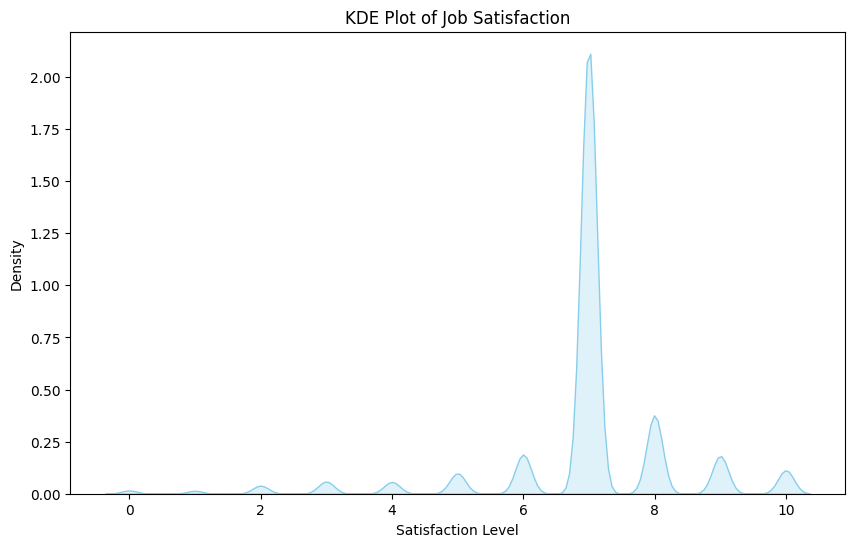

In [18]:
## Write your code here

# Plot the KDE of Job Satisfaction
plt.figure(figsize=(10, 6))
sns.kdeplot(df['JobSat'], fill=True, color='skyblue', bw_adjust=0.8)

plt.title('KDE Plot of Job Satisfaction')
plt.xlabel('Satisfaction Level')
plt.ylabel('Density')
plt.show()

#Interpretation:
#Majority of respondents report a job satisfaction score of ~7, followed by a score of ~8. 
#Few responders scored lower than a 6, indicating that Dev jobs have relatively high job satisfaciton. 



### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


The top 5 languages engineers work with are :             Worked_With  Want_to_Work_With
Language                                  
JavaScript        43184              23774
HTML/CSS          37508              20721
Python            30719              34732
SQL               30682              22400
TypeScript        28842              20239
The top 5 languages engineers want to work with are :             Worked_With  Want_to_Work_With
Language                                  
Python            30719              34732
JavaScript        43184              23774
SQL               30682              22400
HTML/CSS          37508              20721
TypeScript        28842              20239


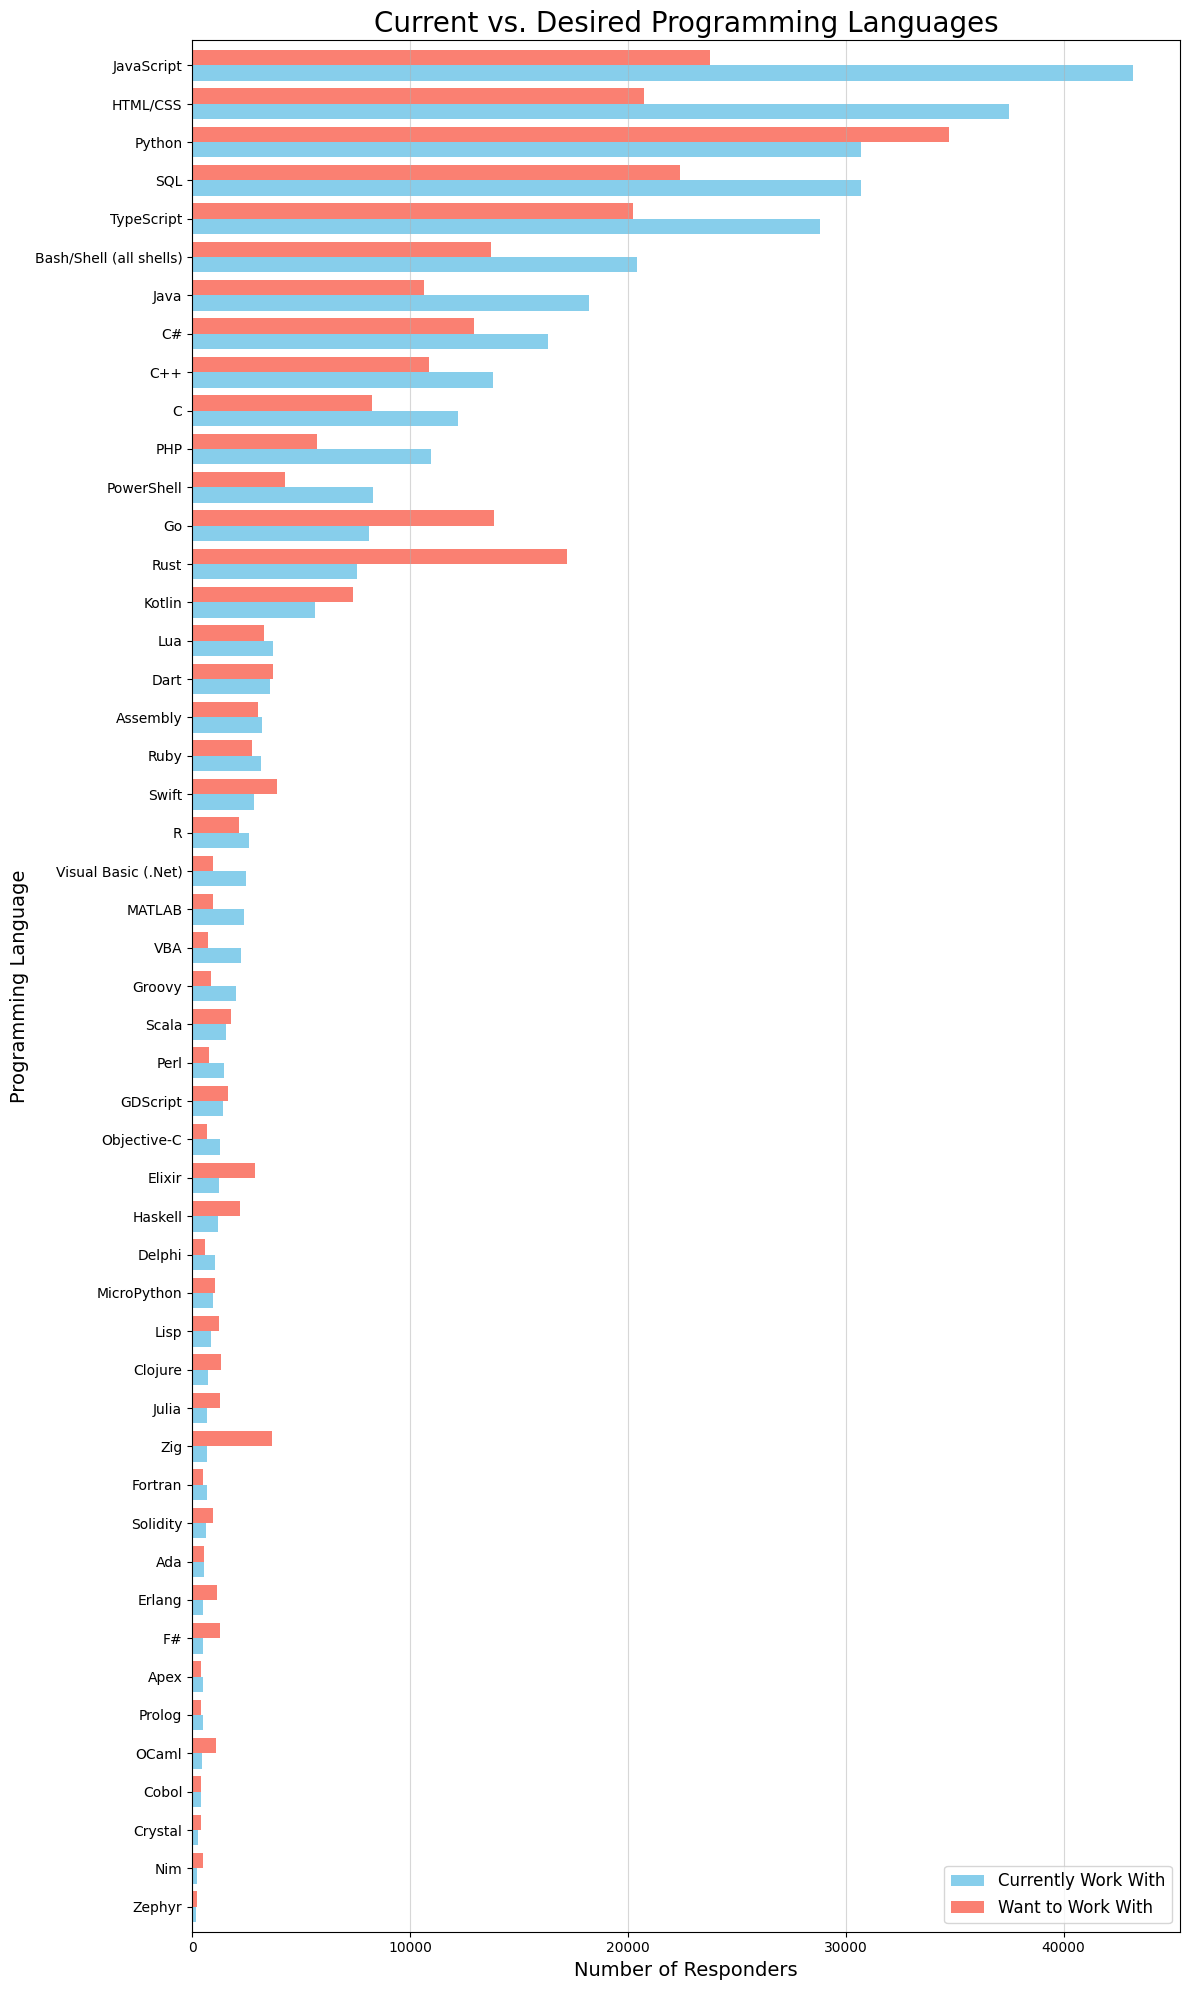

In [31]:
## Write your code here

#Code showing the unique values of LanguageHaveWorkedWith and LanguageWantToWorkWith have multiple data separated by a ;
df['LanguageHaveWorkedWith'].unique()
df['LanguageWantToWorkWith'].unique()

#need to explode/split both datasets
#Change worked with languages into counts
worked = df[['LanguageHaveWorkedWith']].copy()
worked['Language'] = worked['LanguageHaveWorkedWith'].str.split(';')
worked_exploded = worked.explode('Language')
worked_counts = worked_exploded['Language'].value_counts()

#Change want to work with languages into counts
want = df[['LanguageWantToWorkWith']].copy()
want['Language'] = want['LanguageWantToWorkWith'].str.split(';')
want_exploded = want.explode('Language')
want_counts = want_exploded['Language'].value_counts()

#Combine the counts for wants and worked into a table
comparison = pd.DataFrame({
    'Worked_With': worked_counts, 
    'Want_to_Work_With' : want_counts}).astype(int)

#Print top 5 for each want or worked with
print(f'The top 5 languages engineers work with are : {comparison.sort_values(by ='Worked_With', ascending =False).head(5)}')
print(f'The top 5 languages engineers want to work with are : {comparison.sort_values(by ='Want_to_Work_With', ascending =False).head(5)}')


#Need to sort comparisons by value, worked-with
all_langs_sorted = comparison.sort_values(by='Worked_With', ascending=True)

#Create a Grouped Bar Chart
ax = all_langs_sorted.plot(
    kind='barh', 
    figsize=(12, 20),  # Taller than it is wide
    width=0.8, 
    color=['skyblue', 'salmon']
)

plt.title('Current vs. Desired Programming Languages', fontsize=20)
plt.xlabel('Number of Responders', fontsize=14)
plt.ylabel('Programming Language', fontsize=14)
plt.legend(["Currently Work With", "Want to Work With"], loc='lower right', fontsize=12)
plt.grid(axis='x', alpha=0.5)

plt.tight_layout()
plt.show()





### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


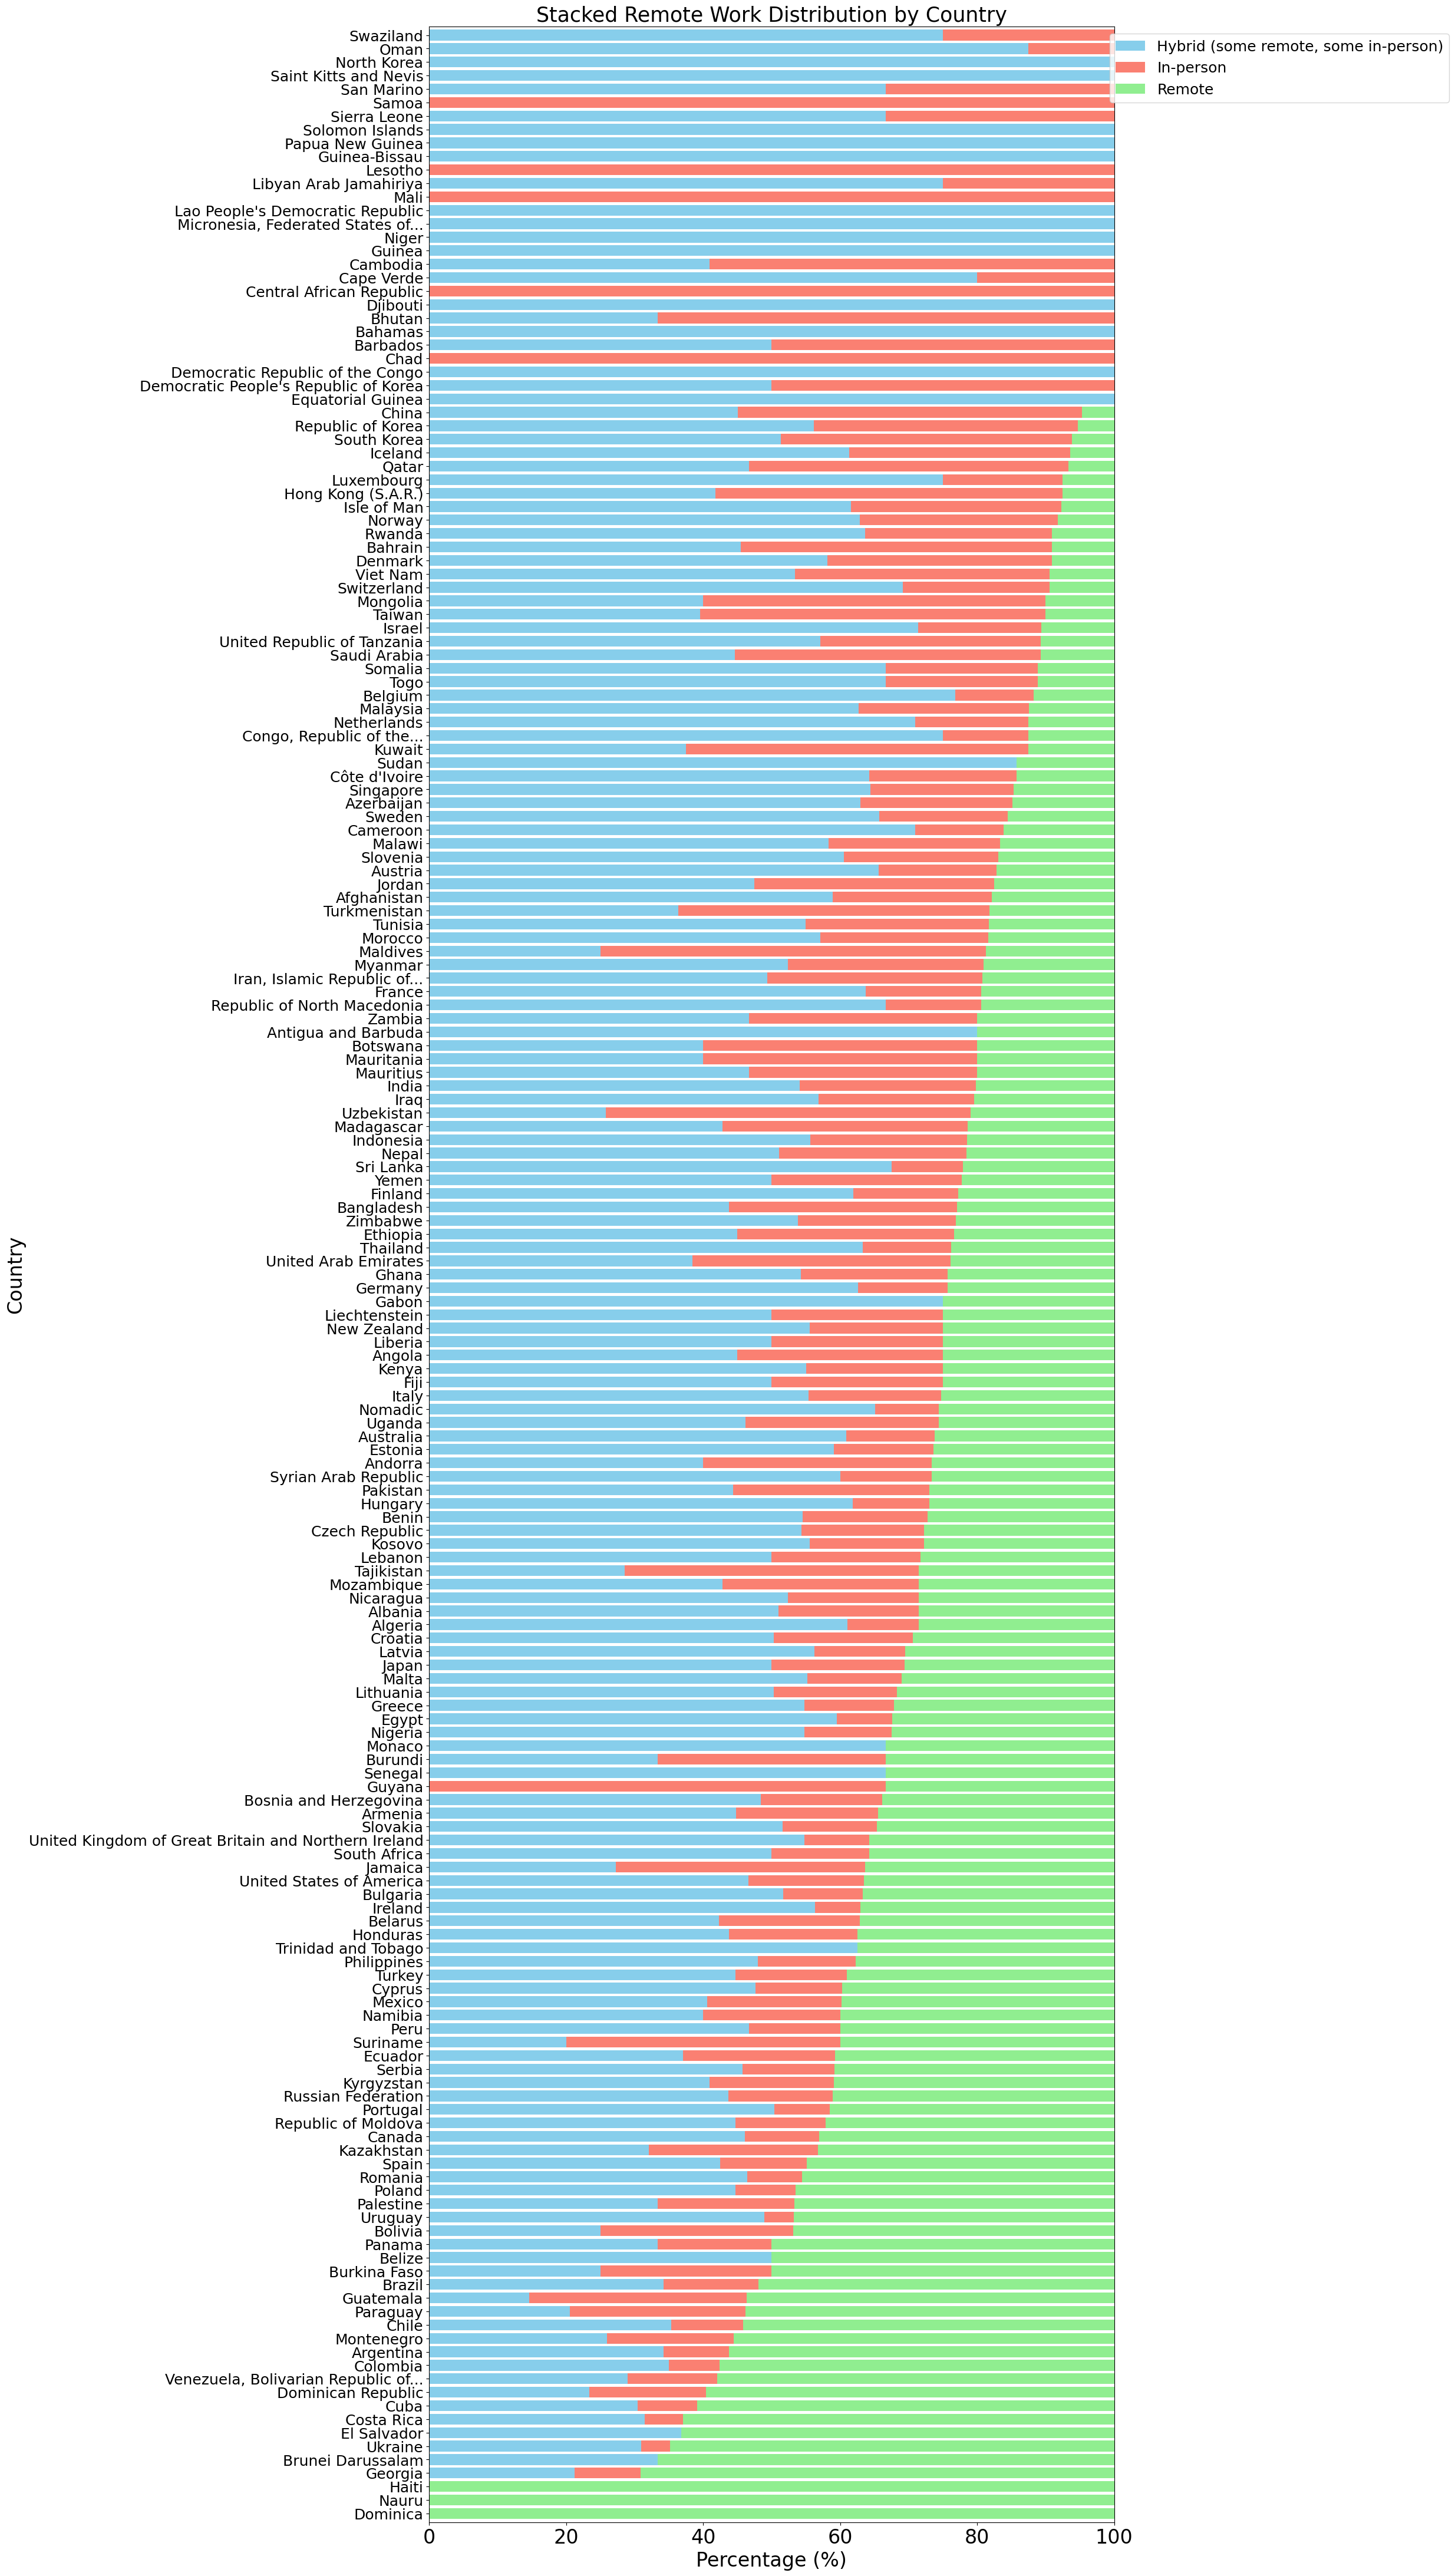

In [45]:
## Write your code here
#Create a cross-tabulation of Country and RemoteWork
# normalize='index' to have each country/rows add up to 100%
remote_xtab = pd.crosstab(df['Country'], df['RemoteWork'], normalize='index') * 100

#Sort by 'Remote' percentage to make trends easier to see
remote_xtab_sorted = remote_xtab.sort_values('Remote', ascending=False)

# Visualize the sorted list as stacked bars
remote_xtab_sorted.plot(kind='barh', figsize=(15, 55), stacked=True, width=0.8, color=['skyblue', 'salmon', 'lightgreen'])

plt.title('Stacked Remote Work Distribution by Country', fontsize=25)
plt.xlabel('Percentage (%)', fontsize=24)
plt.ylabel('Country', fontsize=24)
plt.xticks(fontsize = 24)
plt.yticks(fontsize = 18)
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1), fontsize=18)
plt.show()





### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


[ 2 17 27  7 11 25 12 10  3  0 18 37 15 20  6 16  8 14  4 45  1 24 29  5
 30 26  9 33 13 35 23 22 31 19 21 28 34 32 40 50 39 44 42 41 36 38 51 43
 47 48 46 49]


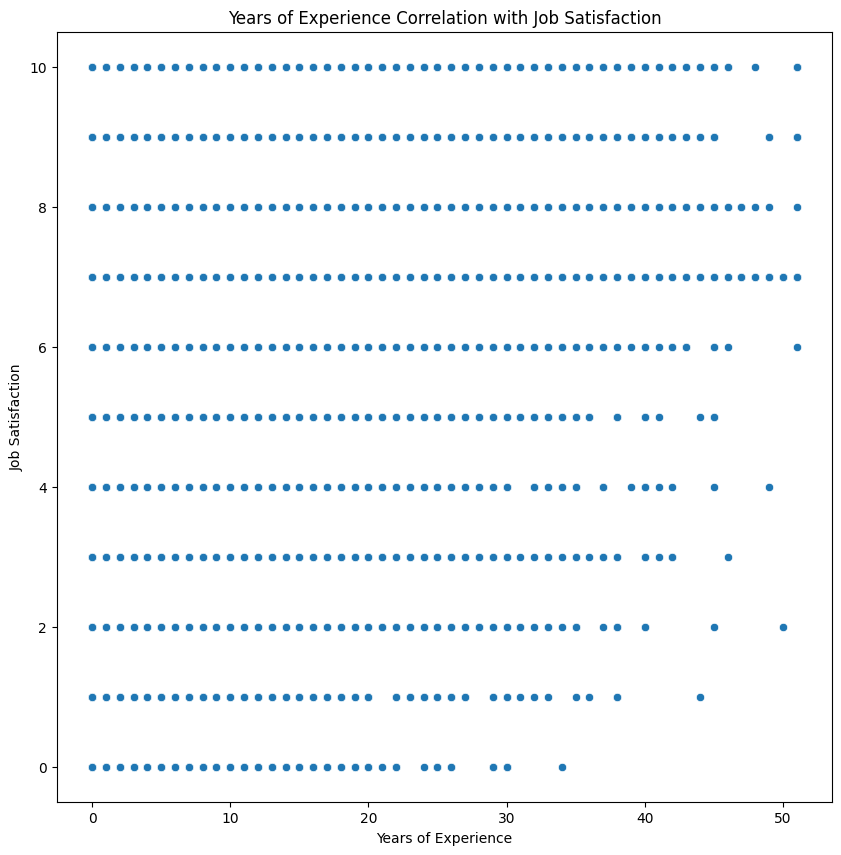

Pearson Correlation: 0.06576238595463287
Spearman Correlation: 0.10482907423246358


In [52]:
## Write your code here

#Need to convert strings to numbers b/c YearsCodePro uses strings and 'less than 1 year' or 'more than 50 years'
unique_vals = df['YearsCodePro'].unique()
print(unique_vals)

#Use dictionary to change some df strings to numbers
df['YearsCodePro'] = df['YearsCodePro'].replace({
    'Less than 1 year': 0, 
    'More than 50 years': 51
})

#Convert all rest of YearsCodePro to numeric 
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'])


#Make the scatter plot
plt.figure(figsize= (10, 10))
sns.scatterplot(data = df, x='YearsCodePro', y='JobSat')
plt.title('Years of Experience Correlation with Job Satisfaction')
plt.xlabel('Years of Experience')
plt.ylabel('Job Satisfaction')
plt.show()

#Calculate pearson and spearman correlation
pearson_corr = df['YearsCodePro'].corr(df['JobSat'], method='pearson')

spearman_corr = df['YearsCodePro'].corr(df['JobSat'], method='spearman')

print(f"Pearson Correlation: {pearson_corr}")
print(f"Spearman Correlation: {spearman_corr}")

### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)



- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


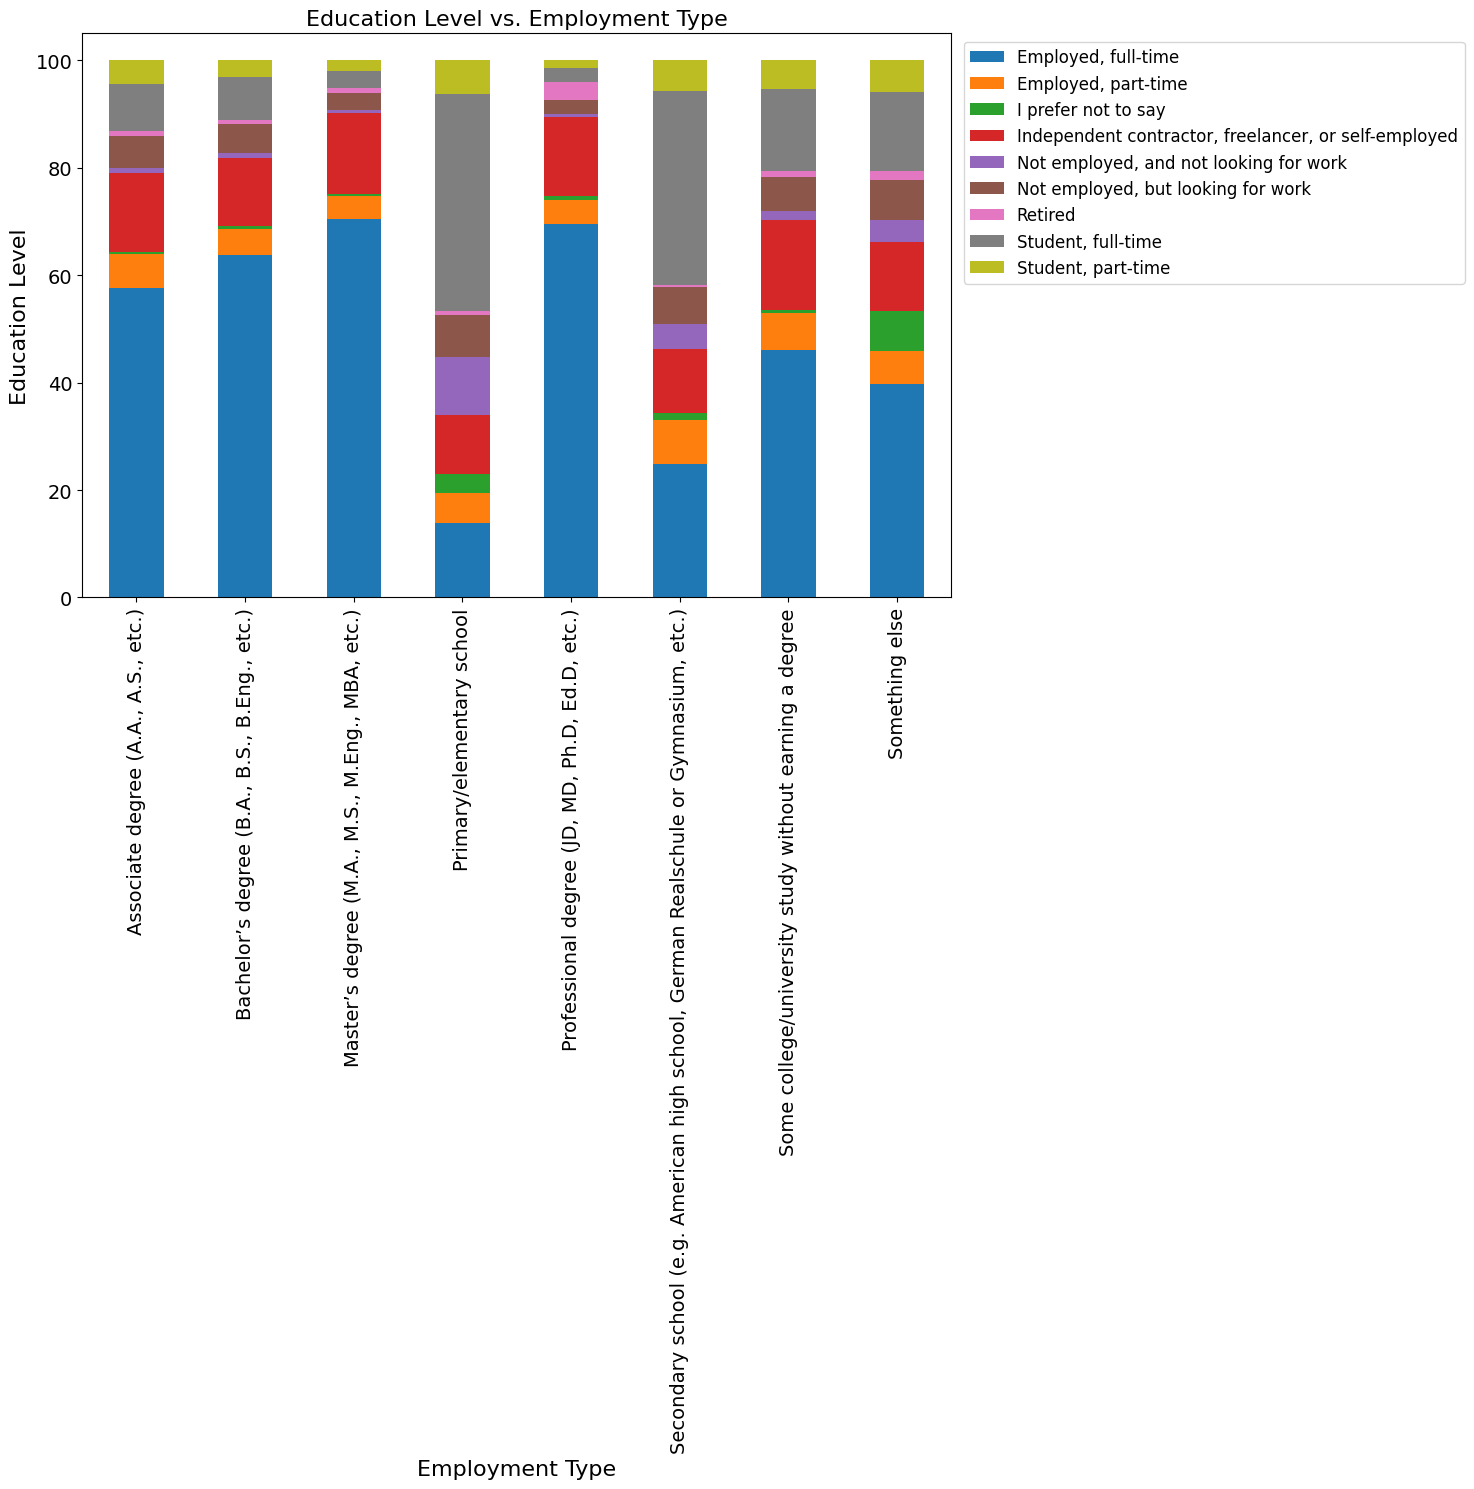

In [65]:
## Write your code here

# make a copy of the original 'df'
xtab_df = df[['EdLevel', 'Employment']].copy()

#Split and Explode the 'Employment' column 
xtab_df['Employment'] = xtab_df['Employment'].str.split(';')
df_exploded = xtab_df.explode('Employment').reset_index(drop=True)

#Generate the cross-tabulation using the exploded data
ex_emp_xtab = pd.crosstab(df_exploded['EdLevel'], 
                          df_exploded['Employment'], 
                          normalize='index') * 100
ex_emp_xtab.head()

#Create stacked bar plot

ax = ex_emp_xtab.plot(kind='bar', stacked=True, figsize=(18, 15))

plt.title('Education Level vs. Employment Type', fontsize=16)
plt.xlabel('Employment Type', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel('Education Level', fontsize=16)
plt.legend(loc='upper right', bbox_to_anchor=(1.6, 1), fontsize=12)
plt.tight_layout()
plt.show()









### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [66]:
## Write your code here
df.to_csv('DF_on_Data_Jobs_2.csv', index=False)

print("Dataset saved successfully as 'DF_on_Data_Jobs_2.csv'")


Dataset saved successfully as 'DF_on_Data_Jobs_2.csv'


### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
